In [1]:
import os
import sys
import matplotlib.pyplot as plt
import torch
import numpy as np

from torch.utils.data import DataLoader
from tqdm import tqdm

# Add the repository root to the python path
sys.path.append(os.path.abspath('/scratch/yl75/ak4177/src/GW_SciML/'))

from src.data.patch_dataset_multi_col import GWPatchDatasetMultiCol
from src.data.data_utils import make_collate_fn
from src.data.batch_sampler import PatchBatchSampler
from src.inference import (
    setup_inference_arguments,
    load_checkpoint,
    create_model_from_checkpoint,
    generate_predictions,
)

from src.models.neuralop.fno import FNOInterpolate

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# BASE_DATA_DIR = "/Users/arpitkapoor/Projects/groundwater/data/feflow_data"
BASE_DATA_DIR = "/scratch/yl75/ak4177/data/feflow_data"
PATCH_DATA_DIR = os.path.join(BASE_DATA_DIR, "patch_all_ts")


In [3]:
ffno_path_chkpnt_path = '/scratch/yl75/ak4177/results/groundwater/FNO/forcing_4d/training_20260827_200238/checkpoints/latest_checkpoint.pth'

In [4]:
chkpnt = load_checkpoint(ffno_path_chkpnt_path)
chkpnt.keys()


Loading checkpoint from: /scratch/yl75/ak4177/results/groundwater/FNO/forcing_4d/training_20260827_200238/checkpoints/latest_checkpoint.pth

Checkpoint configuration found
Checkpoint epoch: 250
Final train loss: 0.1064
Final val loss: 0.1569


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'train_losses', 'train_global_losses', 'train_conc_var_losses', 'val_losses', 'val_global_losses', 'val_conc_var_losses', 'val_epochs', 'args'])

In [5]:
from src.data.data_utils import (
    calculate_coord_transform,
    calculate_obs_transform,
    calculate_forcings_transform,
)

# ── Data transforms (mirrors training setup) ──────────────────────────────
saved_args = chkpnt['args']
RAW_DATA_DIR = saved_args.raw_data_dir  # '/scratch/yl75/ak4177/data/feflow_data/all'

print('Computing coordinate transform...')
coord_transform = calculate_coord_transform(RAW_DATA_DIR)

print('Computing observation transform...')
obs_transform = calculate_obs_transform(
    RAW_DATA_DIR,
    target_obs_cols=['mass_concentration', 'head', 'pressure']
)

forcings_transform = calculate_forcings_transform()

# Map target column names → indices (same as training)
names_to_idx = {'mass_concentration': 0, 'head': 1, 'pressure': 2}
target_col_indices = [names_to_idx[c] for c in saved_args.target_cols]
print(f'Target cols: {saved_args.target_cols} → indices {target_col_indices}')

# ── Build the static-sampled validation dataset ───────────────────────────
resolution_ratio = saved_args.resolution_ratio  # 0.3 from checkpoint
PATCH_DATA_DIR   = saved_args.patch_data_dir

print(f'\nLoading Static Sampled Dataset ({resolution_ratio*100:.1f}% nodes)...')
ds_static = GWPatchDatasetMultiCol(
    data_path=PATCH_DATA_DIR,
    dataset='val',
    coord_transform=coord_transform,
    obs_transform=obs_transform,
    forcings_transform=forcings_transform,
    forcings_required=saved_args.forcings_required,
    target_col_indices=target_col_indices,
    input_window_size=saved_args.input_window_size,
    output_window_size=saved_args.output_window_size,
    resolution_ratio=resolution_ratio,
    sampling_strategy=saved_args.sampling_strategy,
)
print(f'Dataset length: {len(ds_static)}')

Computing coordinate transform...
Coordinate mean: [ 3.57225665e+05  6.45774324e+06 -9.27782248e+00]
Coordinate std: [569.1699999  566.35797379  15.26565618]
Computing observation transform...
Calculating observation transform for columns: ['mass_concentration', 'head', 'pressure']
Output mean: [1.84147516e+04 3.42851163e-01 9.43270494e+01]
Output std: [1.51167586e+04 2.34089747e-01 1.51369751e+02]
Target cols: ['mass_concentration', 'head'] → indices [0, 1]

Loading Static Sampled Dataset (30.0% nodes)...
Loaded time_values.npy: 1909 timesteps, range [0.00, 908.38] days
Static sampling enabled. Uniform patch ratio: 0.3000
Patch 1: subsampling applied (ratio=0.3000). Core nodes 3409 -> 1137, Ghost nodes 170 -> 51
Patch 2: subsampling applied (ratio=0.3000). Core nodes 3332 -> 1111, Ghost nodes 332 -> 99
Patch 3: subsampling applied (ratio=0.3000). Core nodes 4312 -> 1438, Ghost nodes 215 -> 64
Patch 4: subsampling applied (ratio=0.3000). Core nodes 2905 -> 969, Ghost nodes 435 -> 130
P

In [6]:
def define_fno_from_checkpoint(checkpoint, device):
    """
    Create FNOInterpolate model instance from checkpoint configuration.
    
    Args:
        checkpoint (dict): Loaded checkpoint dictionary
        device (str): Device to load model on
        
    Returns:
        FNOInterpolate: Instantiated FNOInterpolate model
    """
    saved_args = checkpoint['args']
    
    model = FNOInterpolate(
        # Coordinate and channel configuration
        coord_dim=saved_args.coord_dim,
        in_channels=saved_args.in_channels,
        out_channels=saved_args.out_channels,
        
        # Latent grid configuration
        latent_query_dims=saved_args.latent_query_dims,
        latent_feature_channels=getattr(saved_args, 'latent_feature_channels', None),
        
        # FNO configuration
        fno_n_layers=saved_args.fno_n_layers,
        fno_n_modes=saved_args.fno_n_modes,
        fno_hidden_channels=saved_args.fno_hidden_channels,
        lifting_channels=saved_args.lifting_channels,
        
        # Projection configuration
        projection_channel_ratio=saved_args.projection_channel_ratio,
        
        # Interpolation settings
        align_corners=getattr(saved_args, 'align_corners', False),
        padding_mode=getattr(saved_args, 'padding_mode', 'border'),
    ).to(device)
    
    return model

In [7]:
model = create_model_from_checkpoint(
    chkpnt,
    model_factory=define_fno_from_checkpoint,
    device=chkpnt['args'].device
)

Using Factorise Space-Time Spectral Conv
Model loaded successfully and set to eval mode


In [8]:
def get_interpolated_grid(model, batch, device):
    """
    Custom forward pass that returns only the interpolated latent grid
    (before FNO processing), useful for visualising the scatter-to-grid
    interpolation step inside FNOInterpolate.

    Returns
    -------
    grid_features : torch.Tensor, shape (batch, C_in, Nx, Ny, Nz, Nt)
        Raw interpolated features on the regular 4-D latent grid.
    latent_queries : torch.Tensor, shape (Nx, Ny, Nz, Nt, 4)
        Grid coordinates (spatial + time) corresponding to each cell.
    """
    input_coords   = batch['input_coords'].to(device).float()   # (N_pts*T_in, 4)
    latent_queries = batch['latent_queries'].to(device).float() # (Nx, Ny, Nz, Nt, 4)
    x              = batch['x'].to(device).float()              # (B, N_pts*T_in, C_in)

    # Squeeze spurious batch dims that broadcast_static_inputs_for_dp would add
    # (single-GPU path: we call the model internals directly)
    if input_coords.ndim == 3:
        input_coords = input_coords.squeeze(0)
    if latent_queries.ndim == len(model.latent_query_dims) + 2:
        latent_queries = latent_queries.squeeze(0)

    spatial_ref = input_coords[:, :model.coord_dim]  # (N_pts*T_in, 3)

    grid_features = model._interpolate_to_grid(
        input_coords, x, spatial_ref, latent_queries
    )  # (B, C_in, Nx, Ny, Nz, Nt)

    return grid_features, latent_queries


print('get_interpolated_grid() defined.')

get_interpolated_grid() defined.


In [9]:
# ── Collate function (must carry _time_values from dataset) ──────────────
saved_args._time_values = ds_static.time_values
saved_args.device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = saved_args.device

collate_fn = make_collate_fn(saved_args, coord_dim=saved_args.coord_dim)

# ── Sampler & DataLoader ──────────────────────────────────────────────────
sampler = PatchBatchSampler(
    ds_static,
    batch_size=saved_args.batch_size,
    shuffle_within_batches=False,
    shuffle_patches=False,
    seed=None
)
loader = DataLoader(ds_static, batch_sampler=sampler, collate_fn=collate_fn)

Building patch groups (one-time operation)...
Building patch_ids cache...
Cached 11080 patch_ids
Found 20 patches with 11080 total samples
Patch sizes: min=554, max=554, avg=554.0
Pre-built 360 batches


In [10]:
print(f'\nLoading Static Sampled Dataset nodes)...')
ds_full = GWPatchDatasetMultiCol(
    data_path=PATCH_DATA_DIR,
    dataset='val',
    coord_transform=coord_transform,
    obs_transform=obs_transform,
    forcings_transform=forcings_transform,
    forcings_required=saved_args.forcings_required,
    target_col_indices=target_col_indices,
    input_window_size=saved_args.input_window_size,
    output_window_size=saved_args.output_window_size,
    resolution_ratio=1.0,
    sampling_strategy=saved_args.sampling_strategy,
)
print(f'Dataset length: {len(ds_full)}')

# ── Sampler & DataLoader ──────────────────────────────────────────────────
ds_full_sampler = PatchBatchSampler(
    ds_full,
    batch_size=saved_args.batch_size,
    shuffle_within_batches=False,
    shuffle_patches=False,
    seed=None
)
ds_full_loader = DataLoader(ds_full, batch_sampler=sampler, collate_fn=collate_fn)


Loading Static Sampled Dataset nodes)...
Loaded time_values.npy: 1909 timesteps, range [0.00, 908.38] days
Static sampling enabled. Uniform patch ratio: 1.0000
Patch 1: no subsampling (ratio=1.0000). Core nodes=3409, Ghost nodes=170
Patch 2: no subsampling (ratio=1.0000). Core nodes=3332, Ghost nodes=332
Patch 3: no subsampling (ratio=1.0000). Core nodes=4312, Ghost nodes=215
Patch 4: no subsampling (ratio=1.0000). Core nodes=2905, Ghost nodes=435
Patch 5: no subsampling (ratio=1.0000). Core nodes=2562, Ghost nodes=128
Patch 6: no subsampling (ratio=1.0000). Core nodes=2898, Ghost nodes=432
Patch 7: no subsampling (ratio=1.0000). Core nodes=4319, Ghost nodes=645
Patch 8: no subsampling (ratio=1.0000). Core nodes=3409, Ghost nodes=340
Patch 9: no subsampling (ratio=1.0000). Core nodes=2569, Ghost nodes=384
Patch 10: no subsampling (ratio=1.0000). Core nodes=3325, Ghost nodes=332
Patch 11: no subsampling (ratio=1.0000). Core nodes=2922, Ghost nodes=292
Patch 12: no subsampling (ratio=1.

In [11]:
# ── Single-batch forward pass to extract the interpolated grid ────────────
model.eval()
with torch.no_grad():
    for batch_idx, batch in enumerate(loader):
        if batch['patch_id'] < 3:
            continue
        grid_features, latent_queries = get_interpolated_grid(model, batch, device)
        print(f'Patch from Batch: {batch["patch_id"]}')
        print(f'grid_features shape : {grid_features.shape}')  # (B, C_in, Nx, Ny, Nz, Nt)
        print(f'latent_queries shape: {latent_queries.shape}') # (Nx, Ny, Nz, Nt, 4)
        # only process the first batch
        break

print('Done. grid_features and latent_queries are ready for visualisation.')

Patch from Batch: 3
grid_features shape : torch.Size([32, 10, 24, 24, 12, 10])
latent_queries shape: torch.Size([24, 24, 12, 10, 4])
Done. grid_features and latent_queries are ready for visualisation.


In [12]:
(B, C_in, Nx, Ny, Nz, Nt) = grid_features.shape
x_grid, y_grid = (latent_queries[:, :, 0, 0, c].cpu().numpy() for c in range(2))


In [13]:
z_vals = latent_queries[0, 0, :, 0, 2].cpu().numpy()
z_vals

array([-0.44034645, -0.19696872,  0.04640901,  0.28978676,  0.5331645 ,
        0.7765422 ,  1.0199199 ,  1.2632976 ,  1.5066754 ,  1.750053  ,
        1.9934309 ,  2.2368085 ], dtype=float32)

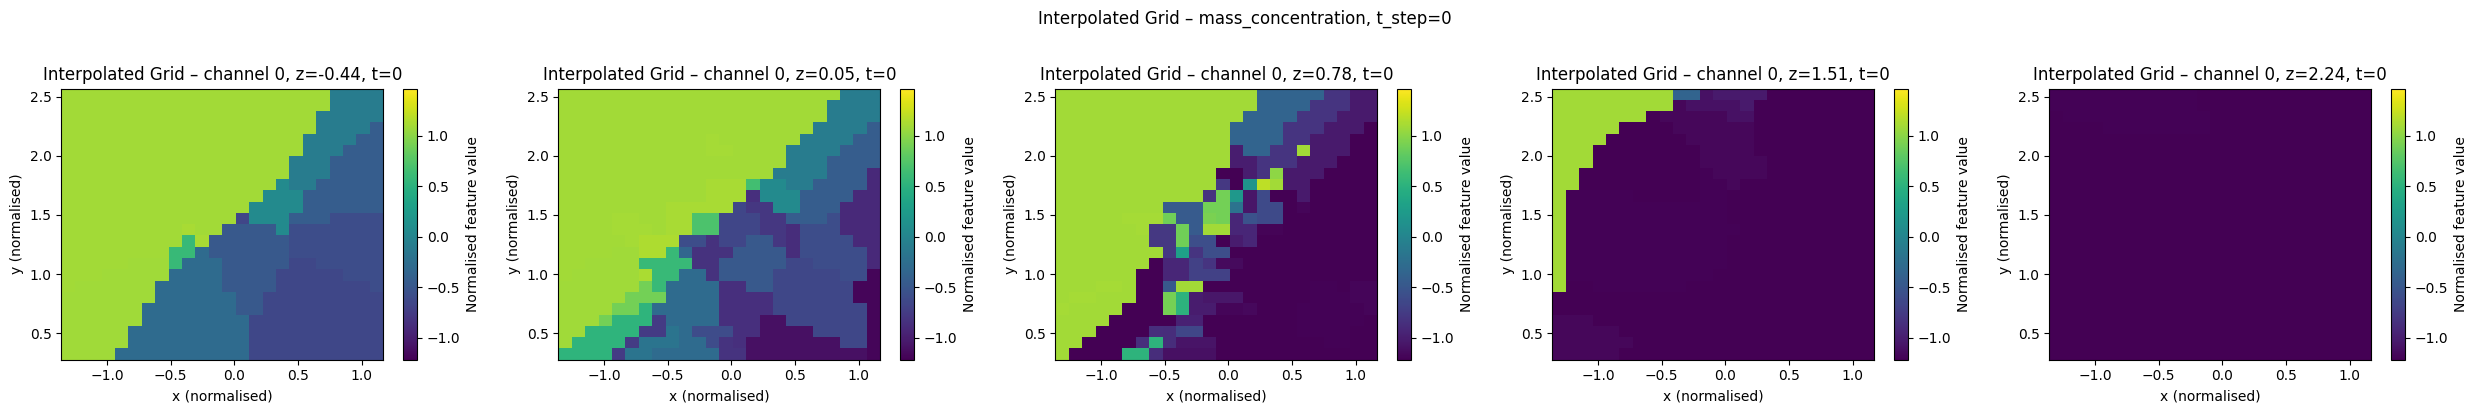

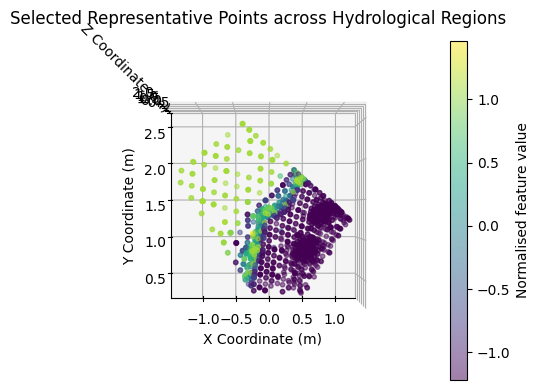

(torch.Size([1502, 3]), torch.Size([1502]))

In [20]:
# ── Multi-Z-level sweep for a chosen channel and time step ───────────────
channel = 0   # 0 = mass_concentration
t_step  = 0

n_cols = min(Nz, 5)  # show at most 6 depth levels
z_levels = np.linspace(0, Nz - 1, n_cols, dtype=int)

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), squeeze=False)

v_min = grid_features[0, channel, :, :, :, t_step].min()
v_max = grid_features[0, channel, :, :, :, t_step].max()

for col_idx, z_lv in enumerate(z_levels):
    slice_2d = grid_features[0, channel, :, :, z_lv, t_step].cpu().numpy()
    ax = axes[0, col_idx]
    pcm = ax.pcolormesh(x_grid, y_grid, slice_2d, cmap='viridis', vmin=v_min, vmax=v_max, shading='auto')
    fig.colorbar(pcm, ax=ax, label='Normalised feature value')
    ax.set_title(f'Interpolated Grid – channel {channel}, z={z_vals[z_lv]:.2f}, t={t_step}')
    ax.set_xlabel('x (normalised)')
    ax.set_ylabel('y (normalised)')

channel_name = saved_args.target_cols[channel] if channel < len(saved_args.target_cols) else f'ch{channel}'
fig.suptitle(f'Interpolated Grid – {channel_name}, t_step={t_step}', y=1.02)
plt.tight_layout()
plt.show()


input_coords = batch['input_coords']

batch_idx = 0
input_array = batch['x']
input_array = input_array[batch_idx]

t_mask = input_coords[:, -1] == input_coords[0, -1]
input_coords = input_coords[t_mask, :3]

channel_idx = 0
input_array = input_array[t_mask, 0]


fig = plt.figure(figsize=(5, 4))
ax3d = fig.add_subplot(111, projection="3d")

scat = ax3d.scatter(input_coords[:, 0], input_coords[:, 1], input_coords[:, 2], c=input_array, vmin=v_min, vmax=v_max, alpha=0.5, s=10)
fig.colorbar(scat, ax=ax3d, label='Normalised feature value')
ax3d.set_title("Selected Representative Points across Hydrological Regions", fontsize=12, pad=12)
ax3d.set_xlabel("X Coordinate (m)", labelpad=10)
ax3d.set_ylabel("Y Coordinate (m)", labelpad=10)
ax3d.set_zlabel("Z Coordinate (m)", labelpad=5)
# ax3d.legend(loc="upper right", frameon=True, framealpha=0.9)
ax3d.set_box_aspect((1, 1, 1.1))
ax3d.view_init(elev=90, azim=270)
plt.tight_layout()
plt.show()

input_coords.shape, input_array.shape

In [15]:
# ── Single-batch forward pass to extract the interpolated grid ────────────
model.eval()
with torch.no_grad():
    for batch_idx, batch_full in enumerate(ds_full_loader):
        if batch_full['patch_id'] < 3:
            continue
        grid_features_full, latent_queries_full = get_interpolated_grid(model, batch_full, device)
        print(f'Patch from Batch: {batch_full["patch_id"]}')
        print(f'grid_features shape : {grid_features.shape}')  # (B, C_in, Nx, Ny, Nz, Nt)
        print(f'latent_queries shape: {latent_queries.shape}') # (Nx, Ny, Nz, Nt, 4)
        break  # only process the first batch

print('Done. grid_features and latent_queries are ready for visualisation.')

Patch from Batch: 3
grid_features shape : torch.Size([32, 10, 24, 24, 12, 10])
latent_queries shape: torch.Size([24, 24, 12, 10, 4])
Done. grid_features and latent_queries are ready for visualisation.


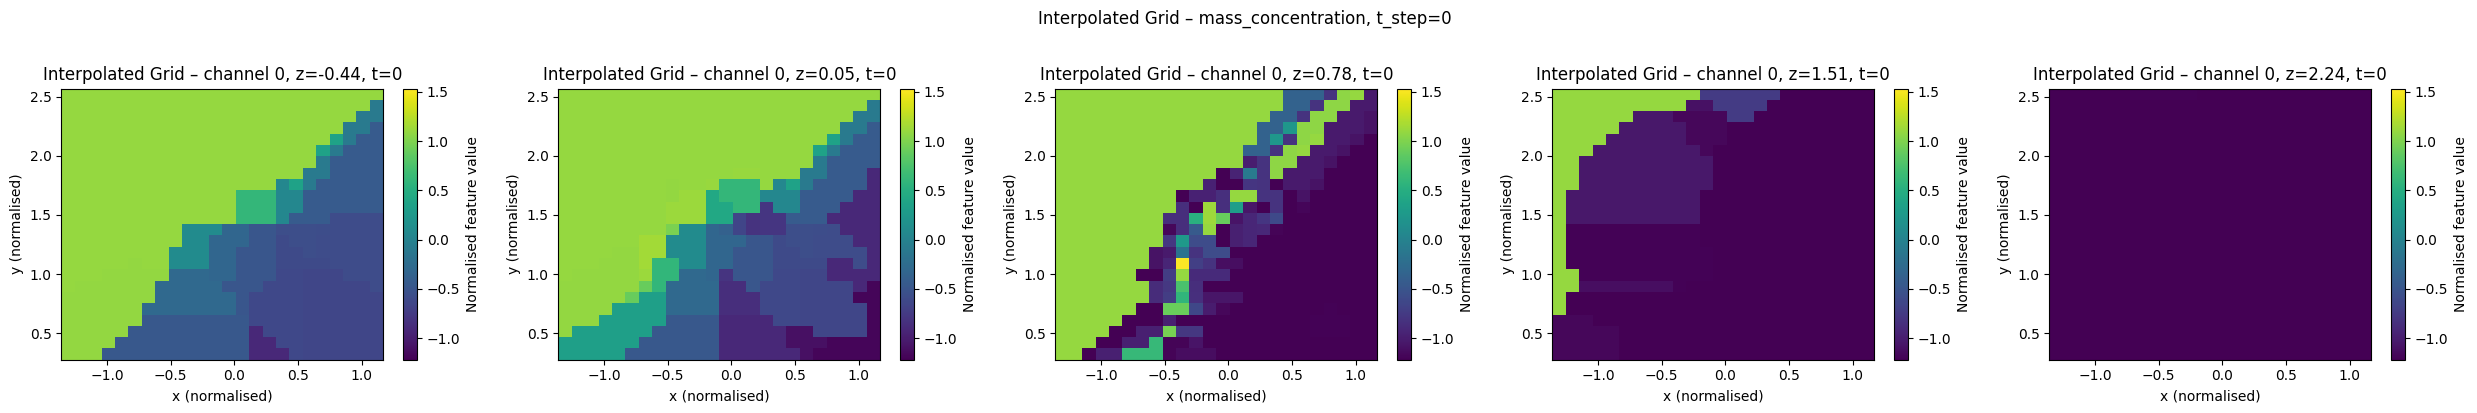

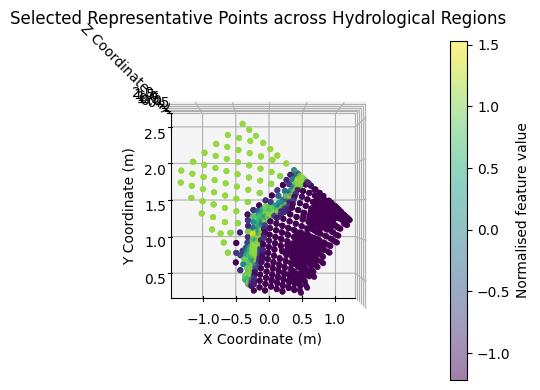

(torch.Size([4527, 3]), torch.Size([4527]))

In [19]:
# ── Multi-Z-level sweep for a chosen channel and time step ───────────────
channel = 0   # 0 = mass_concentration
t_step  = 0

n_cols = min(Nz, 5)  # show at most 6 depth levels
z_levels = np.linspace(0, Nz - 1, n_cols, dtype=int)

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), squeeze=False)

v_min = grid_features_full[0, channel, :, :, :, t_step].min()
v_max = grid_features_full[0, channel, :, :, :, t_step].max()

for col_idx, z_lv in enumerate(z_levels):
    slice_2d = grid_features_full[0, channel, :, :, z_lv, t_step].cpu().numpy()
    ax = axes[0, col_idx]
    pcm = ax.pcolormesh(x_grid, y_grid, slice_2d, cmap='viridis', vmin=v_min, vmax=v_max, shading='auto')
    fig.colorbar(pcm, ax=ax, label='Normalised feature value')
    ax.set_title(f'Interpolated Grid – channel {channel}, z={z_vals[z_lv]:.2f}, t={t_step}')
    ax.set_xlabel('x (normalised)')
    ax.set_ylabel('y (normalised)')

channel_name = saved_args.target_cols[channel] if channel < len(saved_args.target_cols) else f'ch{channel}'
fig.suptitle(f'Interpolated Grid – {channel_name}, t_step={t_step}', y=1.02)
plt.tight_layout()
plt.show()


input_coords = batch_full['input_coords']

batch_idx = 0
input_array = batch_full['x']
input_array = input_array[batch_idx]

t_mask = input_coords[:, -1] == input_coords[0, -1]
input_coords = input_coords[t_mask, :3]

channel_idx = 0
input_array = input_array[t_mask, 0]


fig = plt.figure(figsize=(5, 4))
ax3d = fig.add_subplot(111, projection="3d")

scat = ax3d.scatter(input_coords[:, 0], input_coords[:, 1], input_coords[:, 2], c=input_array, vmin=v_min, vmax=v_max, alpha=0.5, s=10)
fig.colorbar(scat, ax=ax3d, label='Normalised feature value')
ax3d.set_title("Selected Representative Points across Hydrological Regions", fontsize=12, pad=12)
ax3d.set_xlabel("X Coordinate (m)", labelpad=10)
ax3d.set_ylabel("Y Coordinate (m)", labelpad=10)
ax3d.set_zlabel("Z Coordinate (m)", labelpad=5)
# ax3d.legend(loc="upper right", frameon=True, framealpha=0.9)
ax3d.set_box_aspect((1, 1, 1.1))
ax3d.view_init(elev=90, azim=270)
plt.tight_layout()
plt.show()

input_coords.shape, input_array.shape